In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks')

['Untitled', 'dataset.csv', 'cleaned_data.csv', 'Project_file.ipynb']

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.17M/8.17M [00:00<00:00, 76.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


In [6]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset.csv')

In [7]:
df = data.copy()

Data Cleaning

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [9]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [10]:
df = df.drop(columns=df.columns[0])
df.index.name = "index"
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
index,,,,,,,,,,,,,,,,,,,,
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music


In [11]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [12]:
df.shape

(114000, 20)

In [13]:
df.isna().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [14]:
df.duplicated().sum()

np.int64(450)

In [15]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113550 entries, 0 to 113549
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113550 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113550 non-null  int64  
 5   duration_ms       113550 non-null  int64  
 6   explicit          113550 non-null  bool   
 7   danceability      113550 non-null  float64
 8   energy            113550 non-null  float64
 9   key               113550 non-null  int64  
 10  loudness          113550 non-null  float64
 11  mode              113550 non-null  int64  
 12  speechiness       113550 non-null  float64
 13  acousticness      113550 non-null  float64
 14  instrumentalness  113550 non-null  float64
 15  liveness          113550 non-null  float64
 16  valence           11

In [16]:
df.duplicated().sum()

np.int64(0)

Save cleaned dataset

In [17]:
df.to_csv('cleaned_data.csv', index=False)

In [18]:
num = df.select_dtypes(include='number')
cat = df.select_dtypes(exclude='number')

In [62]:
cat


,track_id,artists,album_name,track_name,explicit,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,False,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,False,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,False,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,False,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,False,acoustic
...,...,...,...,...,...,...
113545,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,False,world-music
113546,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,False,world-music
113547,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,False,world-music
113548,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,False,world-music


Business Question 1: Is the artist catalog overly concentrated among a small number of artists, or is it broadly diverse?

Univariate EDA

In [19]:
cat.artists.describe()

,artists
count,113549
unique,31437
top,The Beatles
freq,279


In [20]:
cat.artists.unique()

array(['Gen Hoshino', 'Ben Woodward', 'Ingrid Michaelson;ZAYN', ...,
       'Cuencos Tibetanos Sonidos Relajantes',
       'Bryan & Katie Torwalt;Brock Human', 'Jesus Culture'], dtype=object)

In [21]:
len(cat.artists.unique())

31438

In [22]:
cat.artists.nunique()

31437

In [23]:
cat[cat.artists.isna()]

,track_id,artists,album_name,track_name,explicit,track_genre
65630,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,False,k-pop


In [24]:
cat= cat.dropna(subset=['artists'])

In [25]:
cat.artists.isna().sum()

np.int64(0)

In [26]:
freq = cat.artists.value_counts()
freq

,count
artists,
The Beatles,279
George Jones,260
Stevie Wonder,235
Linkin Park,224
Ella Fitzgerald,221
...,...
Bethel Music;Jenn Johnson;Chris Quilala,1
Hillsong Worship;TAYA;David Ware,1
for KING & COUNTRY;Andy Mineo,1


In [27]:
prop = cat.artists.value_counts(normalize=True)
prop

,proportion
artists,
The Beatles,0.002457
George Jones,0.002290
Stevie Wonder,0.002070
Linkin Park,0.001973
Ella Fitzgerald,0.001946
...,...
Bethel Music;Jenn Johnson;Chris Quilala,0.000009
Hillsong Worship;TAYA;David Ware,0.000009
for KING & COUNTRY;Andy Mineo,0.000009


In [28]:
freq_table = pd.concat([freq, prop*100], axis=1)
freq_table.columns = ['Frequency', 'Proportion']
freq_table

,Frequency,Proportion
artists,,
The Beatles,279,0.245709
George Jones,260,0.228976
Stevie Wonder,235,0.206959
Linkin Park,224,0.197272
Ella Fitzgerald,221,0.194630
...,...,...
Bethel Music;Jenn Johnson;Chris Quilala,1,0.000881
Hillsong Worship;TAYA;David Ware,1,0.000881
for KING & COUNTRY;Andy Mineo,1,0.000881


In [29]:
top20_mostappeared_artists= freq_table.head(20)
top20_mostappeared_artists

,Frequency,Proportion
artists,,
The Beatles,279,0.245709
George Jones,260,0.228976
Stevie Wonder,235,0.206959
Linkin Park,224,0.197272
Ella Fitzgerald,221,0.194630
Prateek Kuhad,217,0.191107
Feid,201,0.177016
Chuck Berry,190,0.167329
Håkan Hellström,183,0.161164


/tmp/ipykernel_1193/1662795673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20_mostappeared_artists, x='artists', y= 'Frequency', palette='magma')


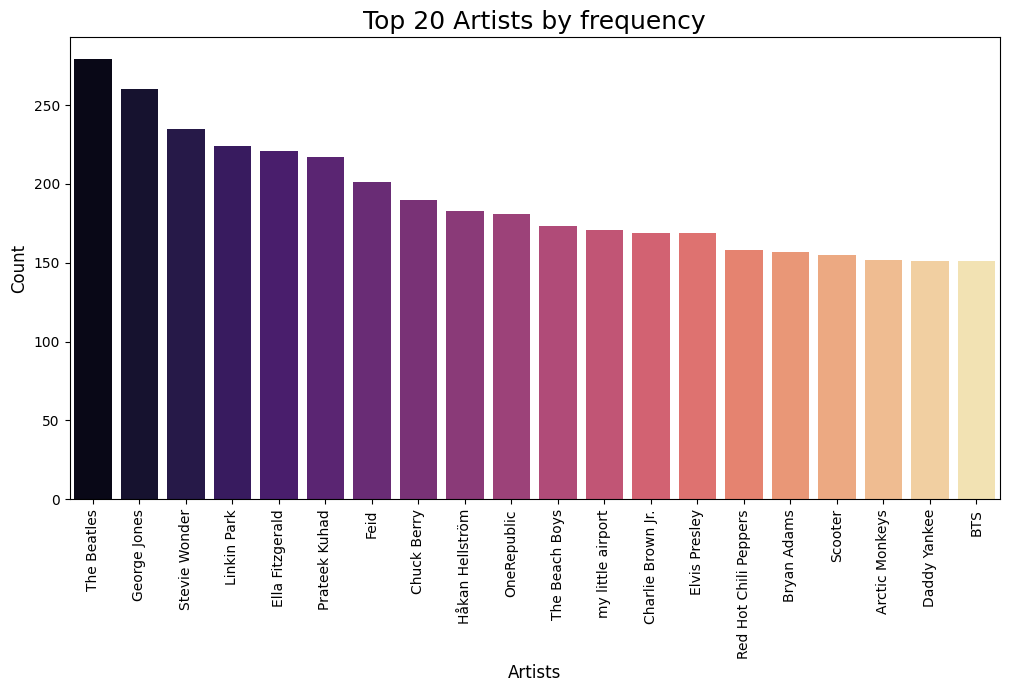

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top20_mostappeared_artists, x='artists', y= 'Frequency', palette='magma')
plt.xlabel("Artists", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Top 20 Artists by frequency", fontsize=18)
plt.xticks(rotation=90)
plt.show()

<Figure size 1200x600 with 0 Axes>

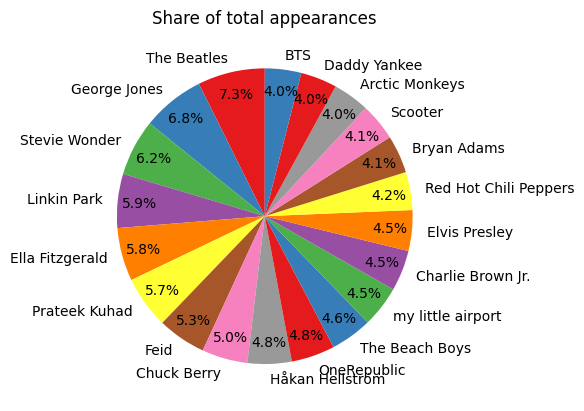

In [31]:
plt.figure(figsize=(12, 6))
top20_mostappeared_artists.plot.pie(y='Proportion', autopct='%1.1f%%' ,pctdistance=0.85, labeldistance=1.1, startangle=90, colors=sns.color_palette('Set1'))
plt.title('Share of total appearances', fontsize=12)
plt.ylabel("")
plt.legend().remove()
plt.show()

Business Question 2: Can a track's tempo (BPM) be used to predict or explain how danceable it is — for example, to support playlist curation or recommendation logic?

Bivariate EDA

In [32]:
num

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113545,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113546,22,385000,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113547,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113548,41,283893,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [33]:
num.tempo.describe()

,tempo
count,113550.000000
mean,122.175888
std,29.972861
min,0.000000
25%,99.296500
50%,122.020000
75%,140.073750
max,243.372000


Tempo describes the beats per minute(BPM) of a track. The min BPM of tempo is found to be 0, which likely is an error, as no song can have 0 BPM. It can be seen that the  most songs cluster around 99 and 140 BPM described by the Q1 and Q3 of tempo. The max tempo is 243 BPM, meaning some songs are very fast.

In [34]:
mean= num.tempo.mean()

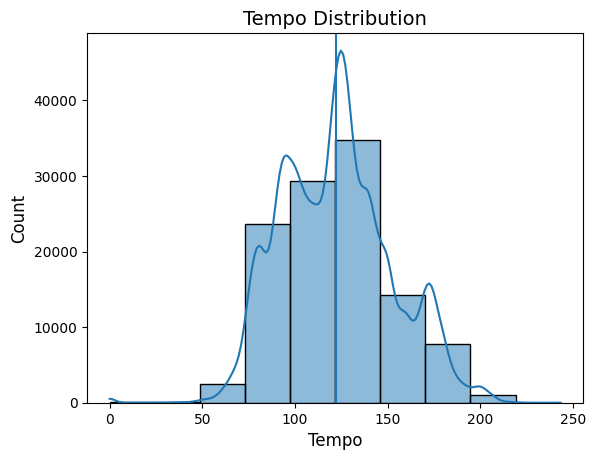

In [35]:
sns.histplot(num.tempo, bins=10, kde=True)
plt.axvline(mean)
plt.xlabel("Tempo", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title('Tempo Distribution', fontsize=14)

plt.show()

The mean appoximately equal to the median. This distribution is symmetric and balance out around the center. It can also be seen from the histogram plot.

In [36]:
num.danceability.describe()

,danceability
count,113550.000000
mean,0.567031
std,0.173408
min,0.000000
25%,0.456000
50%,0.580000
75%,0.695000
max,0.985000


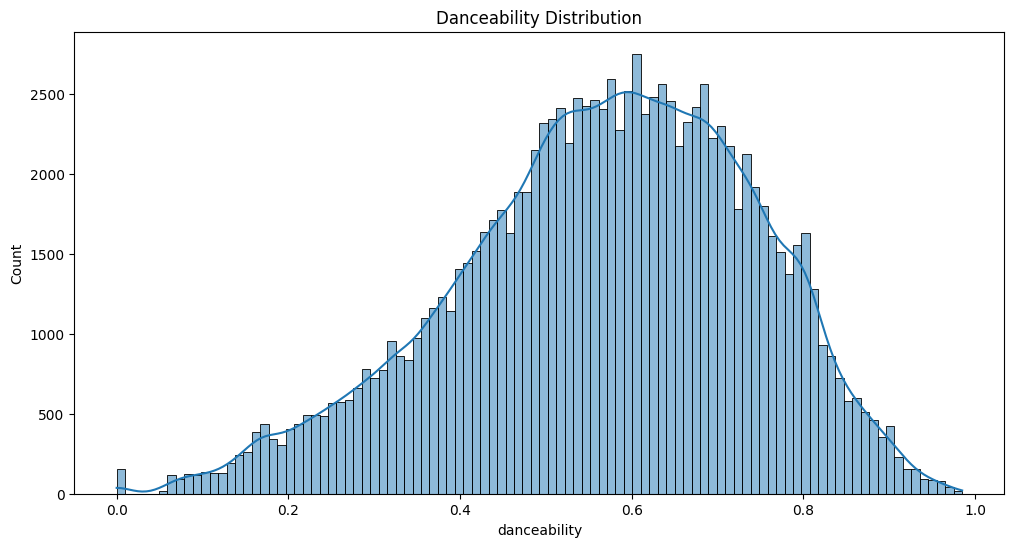

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(num.danceability, kde=True)
plt.title('Danceability Distribution')
plt.show()

Danceability is approximately symmetric with a slight left skew (mean = 0.567, median = 0.58

<function matplotlib.pyplot.show(close=None, block=None)>

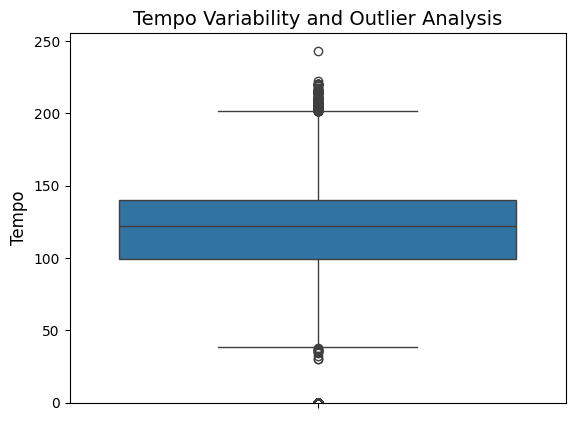

In [38]:
sns.boxplot(data=num, y='tempo')
plt.title('Tempo Variability and Outlier Analysis', fontsize=14)
plt.ylabel("Tempo", fontsize=12)
plt.ylim(0)
plt.show

In [39]:
num = num[num.tempo >0]

In [40]:
num.tempo.describe()

,tempo
count,113393.000000
mean,122.345048
std,29.646587
min,30.200000
25%,99.506000
50%,122.028000
75%,140.081000
max,243.372000


In [41]:
corr1= round(float(num.danceability.corr(num.tempo)), 3)
corr1

-0.071

In [42]:
corr2= round(float(num.danceability.corr(num.tempo, method='spearman')), 3)
corr2

-0.077

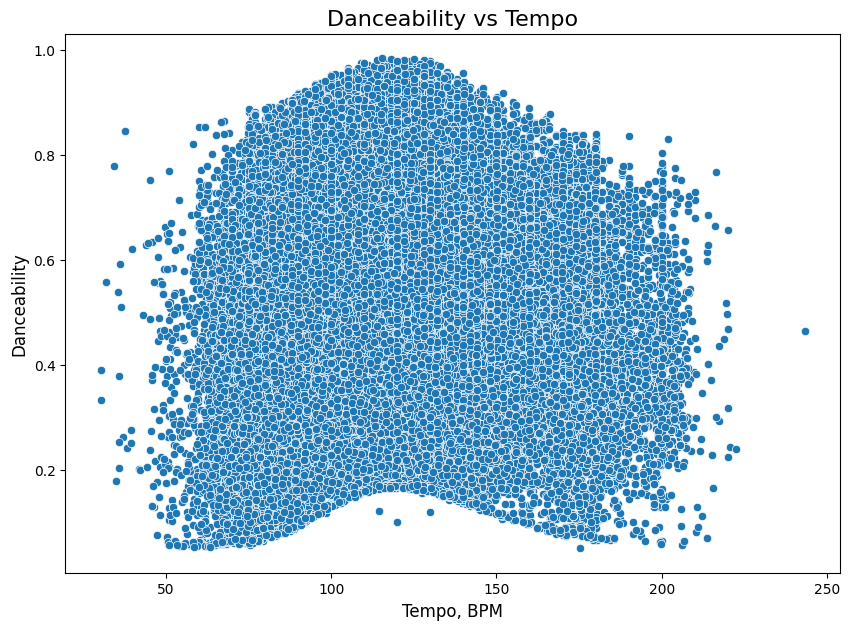

In [43]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=num, x='tempo', y='danceability')
plt.title('Danceability vs Tempo', fontsize=16)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

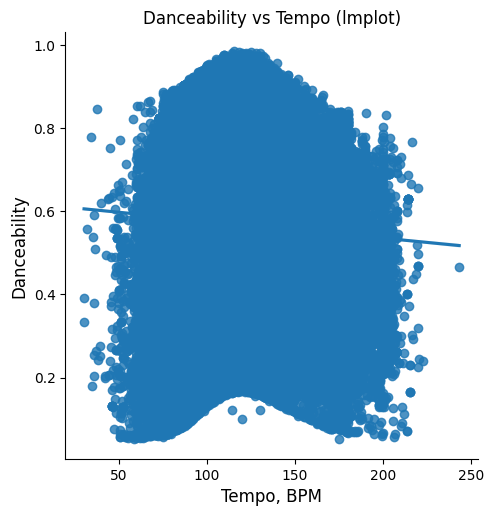

In [44]:
sns.lmplot(data=num, x='tempo', y='danceability')
plt.title('Danceability vs Tempo (lmplot)', fontsize=12)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show

Both Pearson(corr1) and Spearman(corr2) correlation, show no signification correlation between the danceability of a song and the tempo(beats per minute) as both are negative and very close to 0. This is further proven by the scatterplot which show no significant pattern in the plot as the danceability is distributed unevely across the whole tempo range. The plot shows no linear or monotonic correlation.
This can be interpreted as change in the BPM (tempo) does not increase or decrease the danceability of a track.

In [45]:
tempo_median = num.tempo.median()
tempo_median

122.028

To understand this better, the tempo is being divided into 2 categories, first category is to check if there is any correlation between danceability and tempo when BMP increases till the 122 BPM (Median). In the second category, the correlation between these variables beyond the BPM increases above median.

In [46]:
slow_songs =num[num.tempo < tempo_median]
slow_songs

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
4,82,198853,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4
5,58,214240,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.666,98.017,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113540,22,369049,0.579,0.245,4,-16.357,1,0.0384,0.9700,0.924000,0.1010,0.302,112.011,3
113542,38,312566,0.475,0.860,10,-4.722,1,0.0421,0.0065,0.000002,0.2460,0.427,113.949,4
113543,39,256026,0.505,0.687,10,-4.375,1,0.0287,0.0841,0.000000,0.1880,0.382,104.083,3
113546,22,385000,0.174,0.117,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.035,85.239,4


In [47]:
fast_songs = num[num.tempo > tempo_median]
fast_songs

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.90500,0.000071,0.1320,0.1430,181.740,3
6,74,229400,0.407,0.1470,2,-8.822,1,0.0355,0.85700,0.000003,0.0913,0.0765,141.284,3
7,80,242946,0.703,0.4440,11,-9.331,1,0.0417,0.55900,0.000000,0.0973,0.7120,150.960,4
8,74,189613,0.625,0.4140,0,-8.700,1,0.0369,0.29400,0.000000,0.1510,0.6690,130.088,4
11,69,240165,0.483,0.3030,4,-10.058,1,0.0429,0.69400,0.000000,0.1150,0.1390,133.406,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113541,32,250629,0.387,0.5310,8,-4.788,1,0.0290,0.00305,0.000000,0.2010,0.1530,146.003,4
113544,22,305454,0.331,0.1710,1,-15.668,1,0.0350,0.92000,0.022900,0.0679,0.3270,132.147,3
113545,21,384999,0.172,0.2350,5,-16.393,1,0.0422,0.64000,0.928000,0.0863,0.0339,125.995,5
113547,22,271466,0.629,0.3290,0,-10.895,0,0.0420,0.86700,0.000000,0.0839,0.7430,132.378,4


In [48]:
slow_corr1 =round(float(slow_songs.danceability.corr(slow_songs.tempo)), 2)
slow_corr1

0.31

In [49]:
slow_corr2 =round(float(slow_songs.danceability.corr(slow_songs.tempo, method = 'spearman')), 2)
slow_corr2

0.28

<function matplotlib.pyplot.show(close=None, block=None)>

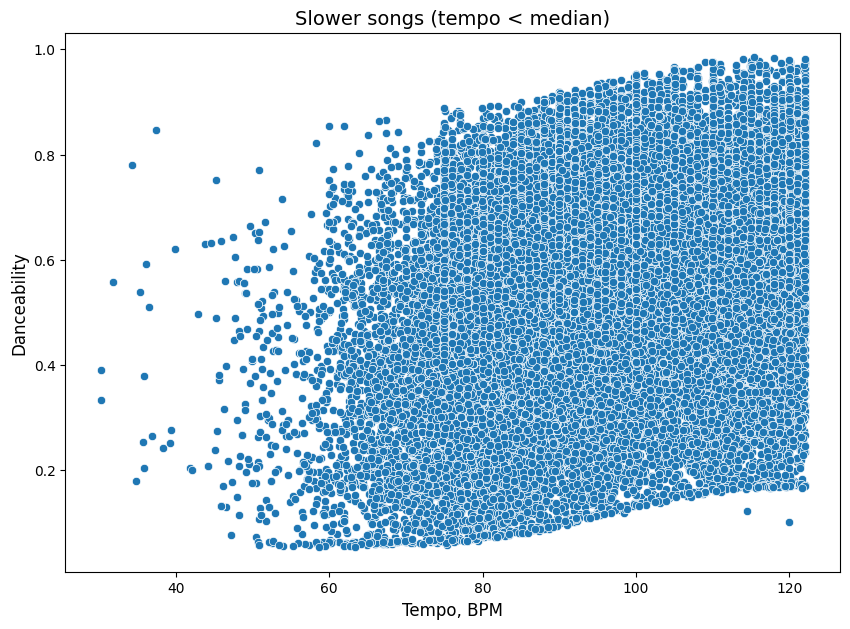

In [50]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=slow_songs, x='tempo', y='danceability')
plt.title('Slower songs (tempo < median)',fontsize=14)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1200x600 with 0 Axes>

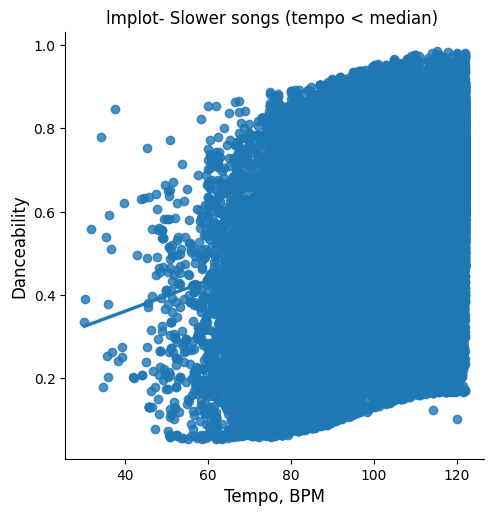

In [51]:
plt.figure(figsize=(12,6))
sns.lmplot(data=slow_songs, x='tempo', y='danceability')
plt.title('lmplot- Slower songs (tempo < median) ', fontsize=12)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show

After spliting the dataset in 2 subset, for the slower songs i.e. songs with tempo below 122 BPM, the danceability tends to increase with the increase in BPM. This is confirmed by the positive Pearson (slow_corr1) and Spearman(slow_corr2) correlation values. This can be further seen from the scatter plot and the lmplot.

In [52]:
fast_corr1=round(float(fast_songs.danceability.corr(fast_songs.tempo)), 2)
fast_corr1

-0.36

In [53]:
fast_corr2=round(float(fast_songs.danceability.corr(fast_songs.tempo, method='spearman')), 2)
fast_corr2

-0.37

<function matplotlib.pyplot.show(close=None, block=None)>

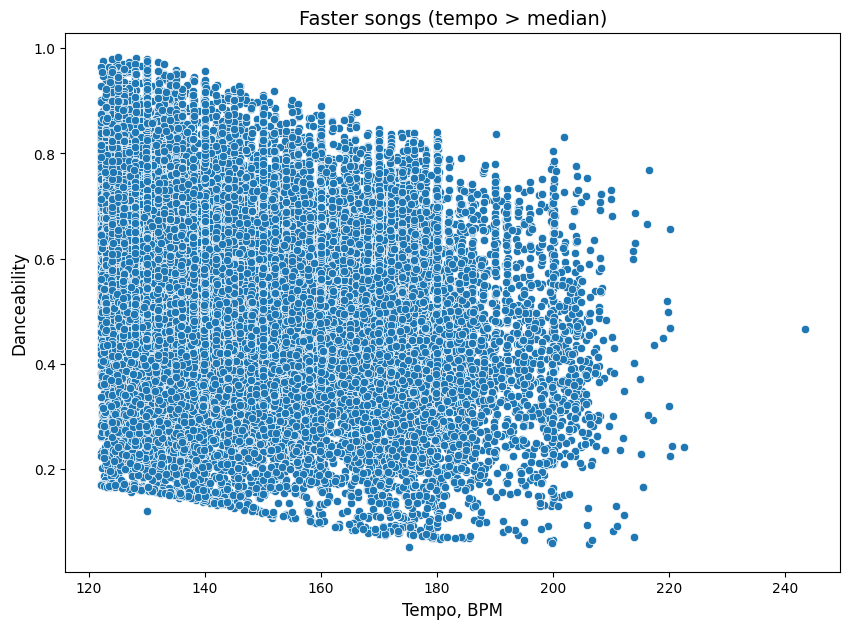

In [54]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=fast_songs, x='tempo', y='danceability')
plt.title('Faster songs (tempo > median)',fontsize=14)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1000x700 with 0 Axes>

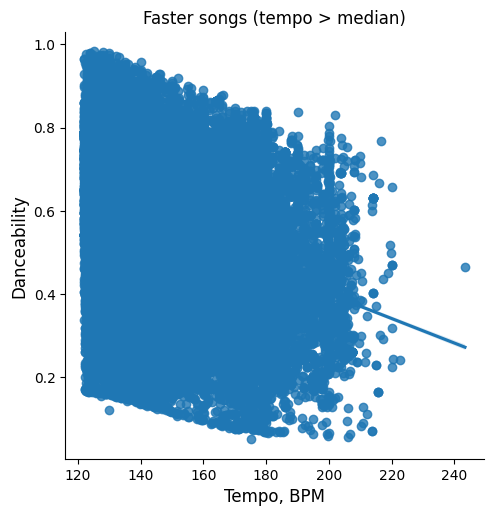

In [55]:
plt.figure(figsize=(10,7))
sns.lmplot(data=fast_songs, x='tempo', y='danceability')
plt.title('Faster songs (tempo > median)',fontsize=12)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)
plt.show

For the faster songs i.e. songs with tempo above 122 BPM, the danceability tends to decrease with the increase in BPM. This is confirmed by the negative Pearson (fast_corr1) and Spearman(fast_corr2) correlation values. This can be further seen from the scatter plot and the lmplot.

Insights:


* Danceability does not have a linear and monotonic relation with the complete tempo group. However, it behaves differently in different tempo subset groups and does have a linear, monotonic relation with each groups of tempo.
* Danceability peaks at mid tempo around 122 BPM (median).
* The overall correlation for the full dataset can be misleading as it combines one positive trend with one negative trend which cancels each other out thereby producing approx 0 correlation. This is a classic example of Simpson's paradox, where combining groups with different behaviours hides meaningful relationships.

In [56]:
slow_songs['tempo_group'] = 'Slow'
fast_songs['tempo_group'] = 'Fast'
combined = pd.concat([slow_songs, fast_songs])

/tmp/ipykernel_1193/2049020113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slow_songs['tempo_group'] = 'Slow'
/tmp/ipykernel_1193/2049020113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fast_songs['tempo_group'] = 'Fast'


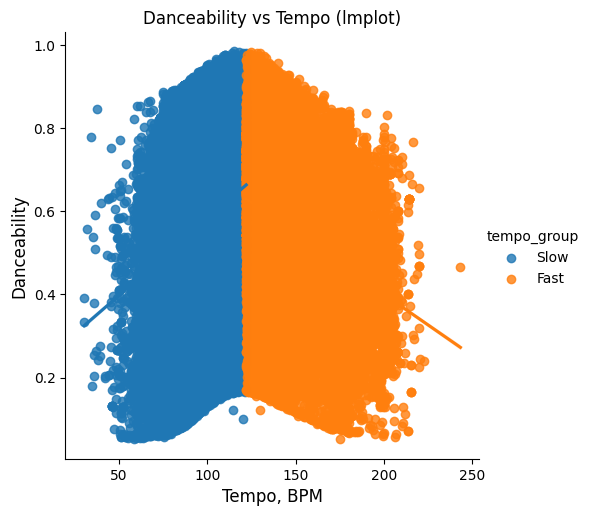

In [57]:
sns.lmplot(data=combined, x='tempo', y='danceability', hue='tempo_group')
plt.title('Danceability vs Tempo (lmplot)', fontsize=12)
plt.xlabel("Tempo, BPM", fontsize=12)
plt.ylabel("Danceability", fontsize=12)

plt.show()

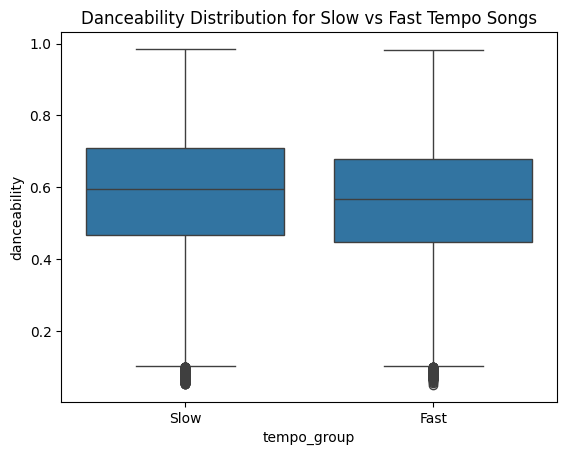

In [58]:
sns.boxplot(data=combined, x='tempo_group', y='danceability')
plt.title('Danceability Distribution for Slow vs Fast Tempo Songs')
plt.show()

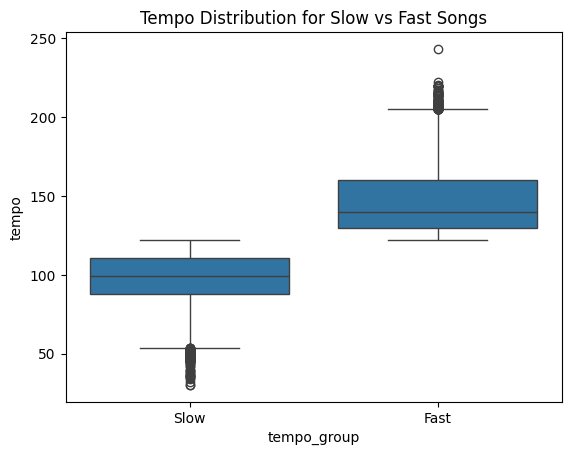

In [59]:
sns.boxplot(data=combined, x='tempo_group', y='tempo')
plt.title('Tempo Distribution for Slow vs Fast Songs')
plt.show()